# Sympy Test Sandbox
### This notebook is used to test various techniques used in typesetting the diagrams for this project.

In [1]:
import matplotlib.pyplot as plt
import math as m
import numpy as np  # 1.7 or higher
from ipywidgets import interactive
from IPython.display import display, Image
import PIL
from io import BytesIO


#from PIL import Image

import qgrid
import pandas as pd

import sympy as sym
sym.init_printing(order="none")
from sympy.vector import CoordSys3D
import sympy.vector as symvec

import scipy

np.set_printoptions(suppress=True, 
                    formatter={'float_kind':'{:14.4f}'.format})  
%matplotlib inline


def display_img_array(ima):
    im = PIL.Image.fromarray(ima)
    bio = BytesIO()
    im.save(bio, format='png')
    display(Image(bio.getvalue(), format='png'))

def display_image(path):
    pil_im = PIL.Image.open(path)
    display(pil_im)

In [2]:
# a list of links that were useful in getting sympy-generated 
# LaTeX'd PDFs into Affinity Designer.  Hint:  Install 
# Latin Modern fonts

# [click me](https://en.wikipedia.org)

# https://medium.com/analytics-vidhya/the-ultimate-markdown-guide-for-jupyter-notebook-d5e5abf728fd
# https://saturncloud.io/blog/how-to-use-latex-in-jupyter-notebook/
# https://docs.sympy.org/latest/tutorials/intro-tutorial/basic_operations.html
# https://tug.org/mactex/
# jupyter nbconvert --to pdf notebook.ipynb
# install Latin Modern OTF fonts for PDF editing in drawing programs
# https://www.gust.org.pl/projects/e-foundry/lm-math
# https://www.gust.org.pl/projects/e-foundry/latin-modern/download
# *** MIGRATING TO NOTEBOOK 7 nbextensions
# https://jupyter-notebook.readthedocs.io/en/latest/migrate_to_notebook7.html


<dl>
<dt>First Term</dt>
<dd>This is the definition of the first term.</dd>
<dt>Second Term</dt>
<dd>This is one definition of the second term. </dd>
<dd>This is another definition of the second term.</dd>
</dl>

In [3]:
# good sympy tutorial 
# https://dynamics-and-control.readthedocs.io/en/latest/0_Getting_Started/Notebook%20introduction.html

x = sym.Symbol('x')
x

In [4]:
# type \gamma<tab> to insert symbol
g = sym.Symbol('γ')
g

In [5]:
# https://docs.sympy.org/latest/modules/vector/
N = CoordSys3D('N')
N.i

In [6]:
v = 2*N.i + N.j
v

In [7]:
k = symvec.Cross(N.i, N.j)
k
#help(symvec.cross)

In [8]:
Vp, Vr = sym.symbols(r'\vec{V_p} \vec{V_r}')
abs(abs(Vr))

In [9]:
#for e in eqs:
#    print(sym.latex(e))

sym.latex(abs(Vr))

'\\left|{\\vec{V_r}}\\right|'

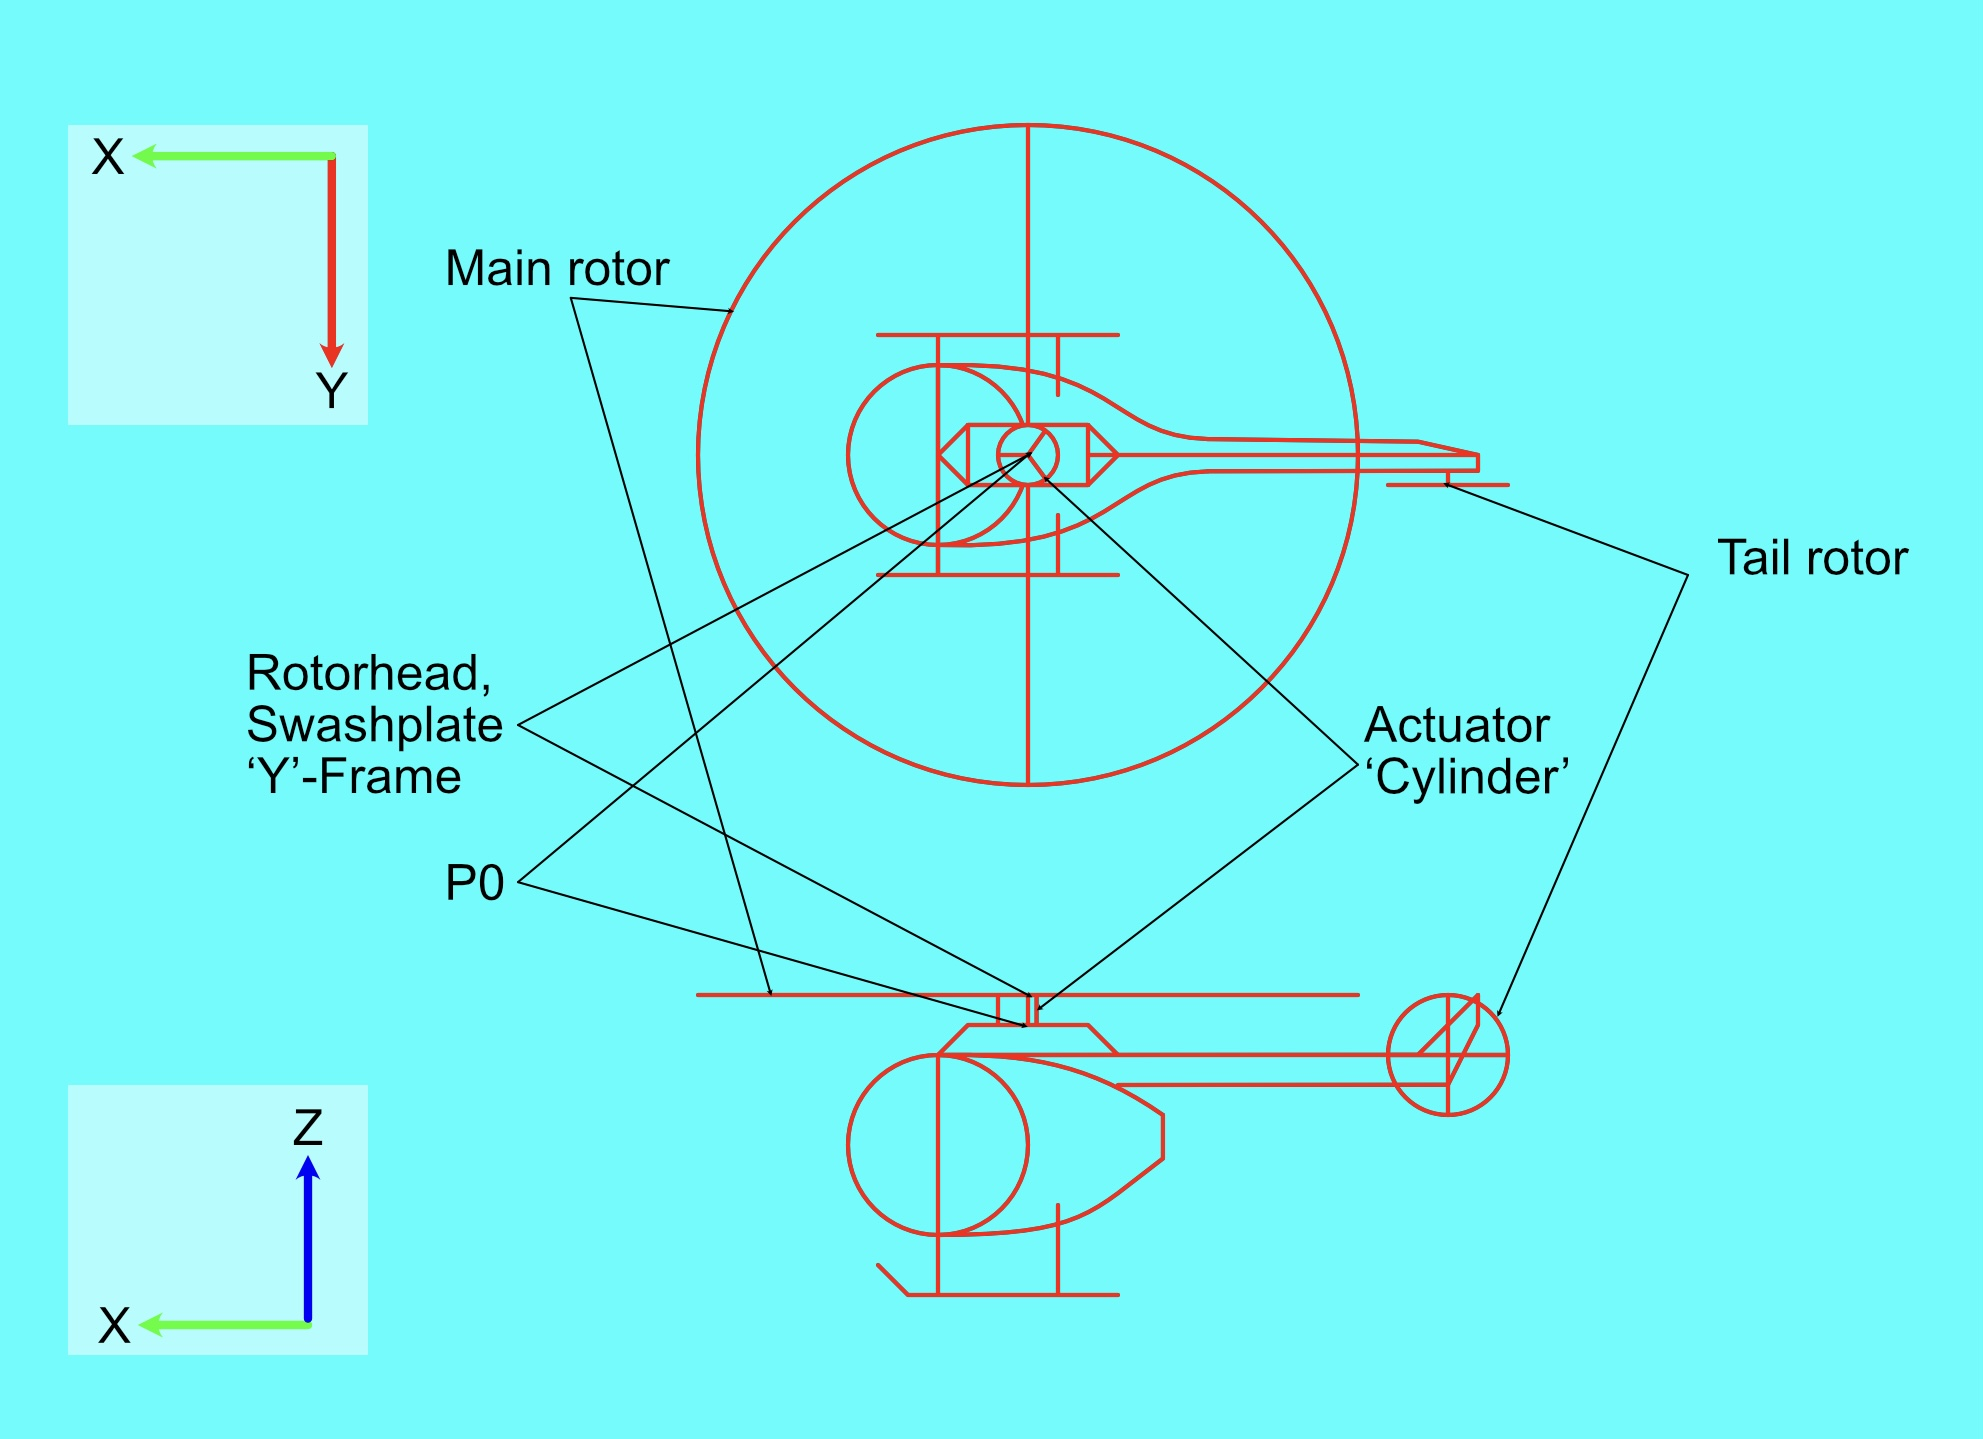

In [10]:
display_image('helidiag.jpg')

In [11]:
from IPython.display import Math

In [12]:
display(Math("{What\ is\ a\ moof?}"+sym.latex(abs(Vr))))




<IPython.core.display.Math object>

In [13]:
from sympy.physics.units import newton, centimeter, kilogram, gram, meter, second, gravitational_constant

In [14]:
1.8*newton*meter

1.8⋅meter⋅newton

In [15]:
15*kilogram*centimeter

15⋅centimeter⋅kilogram

In [16]:
gravitational_constant/newton

gravitational_constant
──────────────────────
        newton        

In [17]:
gac = 9.81*meter/second**2
gac

9.81⋅meter
──────────
       2  
 second   

In [18]:
k = (15*kilogram*gac)
k

147.15⋅kilogram⋅meter
─────────────────────
             2       
       second        

In [19]:
from sympy.physics.units.util import quantity_simplify

In [20]:
quantity_simplify(k)

147.15⋅kilogram⋅meter
─────────────────────
             2       
       second        

### Importing into github
#### I always get this wrong the first eight tries.

https://docs.github.com/en/migrations/importing-source-code/using-the-command-line-to-import-source-code/adding-locally-hosted-code-to-github

if not already setup:

```
123  git config --global --edit
```

```
  126  git init -b main
  127  git add .
  128  git commit -m "First commit"
  129  git remote add origin https://github.com/ivorjawa/Mecanum_lego.git
  130  git remote -v
  131  git push -u origin main
  132  git pull origin main
  # 133  git config pull.rebase false
  # 134  git pull origin main
  135  git config pull.rebase true
  136  git pull origin main
  138  git push -u origin main
```

may need to do a "git checkout -b main" before push to satisfy github.
if origin push fails, "git config http.postBuffer 524288000" may work

In [21]:
import cv2


In [22]:
help(display)

Help on function display in module IPython.core.display_functions:

display(*objs, include=None, exclude=None, metadata=None, transient=None, display_id=None, raw=False, clear=False, **kwargs)
    Display a Python object in all frontends.
    
    By default all representations will be computed and sent to the frontends.
    Frontends can decide which representation is used and how.
    
    In terminal IPython this will be similar to using :func:`print`, for use in richer
    frontends see Jupyter notebook examples with rich display logic.
    
    Parameters
    ----------
    *objs : object
        The Python objects to display.
    raw : bool, optional
        Are the objects to be displayed already mimetype-keyed dicts of raw display data,
        or Python objects that need to be formatted before display? [default: False]
    include : list, tuple or set, optional
        A list of format type strings (MIME types) to include in the
        format data dict. If this is set *only* 

tag: red27 id: 27
tag: blue03 id: 3
tag: green15 id: 15
tag: bubble id: 42


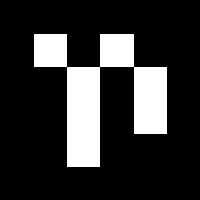

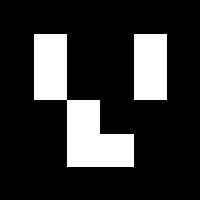

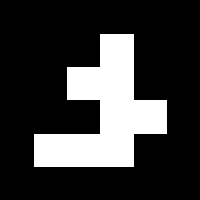

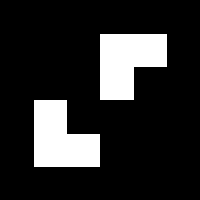

In [23]:
tags = {
    'red27': 27,
    'blue03': 3,
    'green15': 15,
    'bubble': 42,
}

markers = []
for (name, marker_id) in tags.items():
    print(f"tag: {name} id: {marker_id}")
    dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_250)
    #marker_id = 0 # max 249 
    marker_size = 200
    marker_image = cv2.aruco.generateImageMarker(dictionary, marker_id, marker_size)
    #display(plt.imshow(marker_image))
    #markers.append(plt.imshow(marker_image))
    markers.append(marker_image)
    
    tag_name = f"aruco/markers/aruco_{name}_{marker_id}.png"
    cv2.imwrite(tag_name, marker_image)


for ima in markers:
    display_img_array(ima)
    
#

In [24]:
# https://docs.opencv.org/4.x/da/d0d/tutorial_camera_calibration_pattern.html
# https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html

In [25]:
# to remove crlf:
# vim file.txt -c "set ff=unix" -c ":wq"

In [26]:
import svgwrite, base64

''
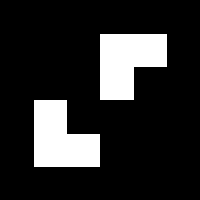

In [27]:
dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_250)
marker_size = 200
marker_image = cv2.aruco.generateImageMarker(dictionary, 42, marker_size)
marker_image.shape
img_encode = cv2.imencode('.png', marker_image)[1]
# Converting the image into numpy array 
#data_encode = np.array(img_encode) 
# Converting the array to bytes. 
#byte_encode = data_encode.tobytes()
byte_encode = img_encode.tobytes()
bbytes = base64.b64encode(byte_encode).decode()
xlink = f"data:image/png;base64,{bbytes}"
xlink

In [28]:
x = [30*(z-12) for z in range(25)]
for ang in x:
    print(f"{ang:5} {(90-(ang%180)):5}")

 -360    90
 -330    60
 -300    30
 -270     0
 -240   -30
 -210   -60
 -180    90
 -150    60
 -120    30
  -90     0
  -60   -30
  -30   -60
    0    90
   30    60
   60    30
   90     0
  120   -30
  150   -60
  180    90
  210    60
  240    30
  270     0
  300   -30
  330   -60
  360    90


In [29]:
steps = np.arange(0, 11, 1)*36
r = 50
x = r*np.cos(np.radians(steps))
y = r*np.sin(np.radians(steps))
z = 0 * steps
np.stack([x, y, z], axis=1)

array([[       50.0000,         0.0000,         0.0000],
       [       40.4508,        29.3893,         0.0000],
       [       15.4508,        47.5528,         0.0000],
       [      -15.4508,        47.5528,         0.0000],
       [      -40.4508,        29.3893,         0.0000],
       [      -50.0000,         0.0000,         0.0000],
       [      -40.4508,       -29.3893,         0.0000],
       [      -15.4508,       -47.5528,         0.0000],
       [       15.4508,       -47.5528,         0.0000],
       [       40.4508,       -29.3893,         0.0000],
       [       50.0000,        -0.0000,         0.0000]])

In [30]:
help(cv2.fillPoly)

Help on built-in function fillPoly:

fillPoly(...)
    fillPoly(img, pts, color[, lineType[, shift[, offset]]]) -> img
    .   @brief Fills the area bounded by one or more polygons.
    .   
    .   The function cv::fillPoly fills an area bounded by several polygonal contours. The function can fill
    .   complex areas, for example, areas with holes, contours with self-intersections (some of their
    .   parts), and so forth.
    .   
    .   @param img Image.
    .   @param pts Array of polygons where each polygon is represented as an array of points.
    .   @param color Polygon color.
    .   @param lineType Type of the polygon boundaries. See #LineTypes
    .   @param shift Number of fractional bits in the vertex coordinates.
    .   @param offset Optional offset of all points of the contours.



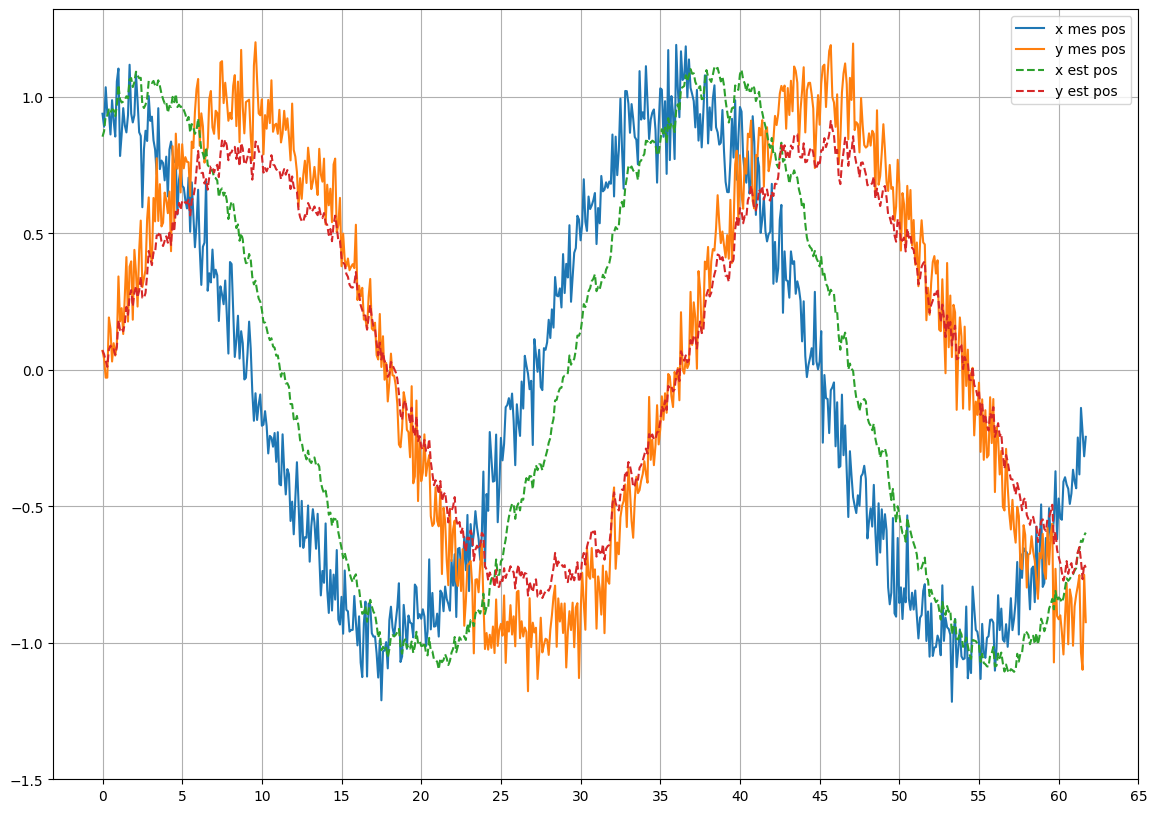

In [31]:
# Define time step
dt = 0.1

# Initialize the filter with an initial estimate of the state matrix and the associated uncertainty (covariance)
x_estimated = np.array([[0], [0], [0], [0]])
P_estimated = np.eye(4)

# Define the state transition matrix
A = np.array([[1, dt, 0, 0], [0, 1, 0, 0], [0, 0, 1, dt], [0, 0, 0, 1]])

# Define the control input matrix as 0
B = np.array([[0], [0], [0], [0]])

# Define the control input as 0
u = np.array([[0], [0], [0], [0]])

# Define the measurement matrix
H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])

# Define the measurement noise
R = np.array([[0.1, 0], [0, 0.1]])

# Define the process noise
Q = np.array([
        [0.01, 0.01, 0.01, 0.01], 
        [0.01, 0.02, 0.01, 0.01], 
        [0.01, 0.01, 0.03, 0.01], 
        [0.01, 0.01, 0.01, 0.04]])

xp = []
xmp = []
yp = []
ymp = []
xv = []
yv = []
for i in range(618):
    # Generate a measurement with some random noise
    #measurement = np.array([[i + np.random.normal(0, 0.1)], [i + np.random.normal(0, 0.1)]])
    measurement = np.array([[np.cos(m.radians(i)) + np.random.normal(0, 0.1)], [np.sin(m.radians(i)) + np.random.normal(0, 0.1)]])



    # Prediction step
    x_predicted = np.dot(A, x_estimated)# + np.dot(B, u)
    P_predicted = np.dot(A, np.dot(P_estimated, A.T)) + Q

    # Correction step
    K = np.dot(P_predicted, np.dot(H.T, np.linalg.inv(np.dot(H, np.dot(P_predicted, H.T)) + R)))
    x_estimated = x_predicted + np.dot(K, (measurement - np.dot(H, x_predicted)))
    P_estimated = np.dot((np.eye(4) - np.dot(K, H)), P_predicted)

    xmp.append(measurement[0])
    ymp.append(measurement[1])

    # Print the estimated position and velocity
    #print("Estimated x_position: ", x_estimated[0][0])
    xp.append(x_estimated[0][0])
    #print("Estimated y_position: ", x_estimated[1][0])
    yp.append(x_estimated[1][0])
    #print("Estimated x_velocity: ", x_estimated[2][0])
    xv.append(x_estimated[2][0])
    #print("Estimated y_velocity: ", x_estimated[3][0])
    yv.append(x_estimated[3][0])
    
    
fig, ax = plt.subplots(figsize=(14, 10))
#ax.set_aspect('equal')

tim = np.array(range(len(xp)))*dt

#ax.plot(xmp, ymp, label = "measured")
#ax.plot(xp, yp, label = "predicted")


ax.plot(tim, xmp, label='x mes pos')
ax.plot(tim, ymp, label='y mes pos')
ax.plot(tim, xp, '--', label='x est pos')
ax.plot(tim, yp, '--',label='y est pos')
ax.set_xticks(np.arange(0, 70, 5))
ax.set_yticks(np.arange(-1.5, 1.5, .5))


ax.grid()
#ax.plot(tim, xv, label='x est vel')
#ax.plot(tim, yv, label='x est vel')



#ax.set_title("Joystick characterization")
#ax.set_xlabel("Time(ms)")

ax.legend()

### Random to-dos

* Make poster of first and second order system properties 
* Back-calculate balance from ball moment of inertia
* Once we have sufficient leveling data, we should be able to use the red ball with a step test to calibrate. 
* Why not make camera frame over robot racetrack with Kinect?
* Measure level in all 4 corners to determine optical error. Measure from center at many angles. IMU data. 
* Threshold in addition to contrast and blurring
* https://www.precisionmicrodrives.com/dc-motor-speed-voltage-and-torque-relationships
* What is relation of output torque to input voltage in dc motor?  Treat platform as two dc motors with dummy lump black box model derived from testing
* Get estimate of gravity vector from brick imu. How far off from bubble test?
* Off-center bubble will have some error, can we compensate if we know r to center? I think so. 
* Calibration step every run?  Move platform as high as possible while still maneuverable, opencv program to find bubble anywhere on plate
* Bubble bias test should just yield x and y rotation angles
* Model system with servo model estimate serially applied and driven as “torque” as in umich model, recalculate stability etc
* Add flag for ball detected and zero ball data when not so we handle ball removal with logging gracefully/ also lead lag compensator
* x Draw diagram of system components and orientations so we can stop inserting random minus signs.  Camera to table and joystick inputs. Fix all the things!
* x Add aimpoint cursor and ability to set aimpoint so we can always converge there
* Try to modulate Moira / Cubase Video Tutorial - Vocoder (Transformers Style) https://youtu.be/D_bwIjc9DP0?si=TXWixwl72KdXCHdm
* Can do basic SLAM with mechbot by scanning 360°, slowly with sonar, then move to unexplored parts of grid space. Log color sensor data too. Robust Odometry and Fully Autonomous Driving Robot |  ATCrawler x FAST-L... https://youtu.be/0oBHPxRycTk?si=DcDh4NTxiN2OvpEU
* Kalman covariant mat use estimate of likely ex dy per frame
* Animate cursor going to random grid (maybe with some added noise/curves zeroing descending trumpet) before A* lightning with ball held static. Scanning for target. 
* Terminator grid planning
*    Random (1-10) rounds of selection when ball is held steady
*    Random x, y chosen for each
*    Animate each chosen point
*    Blink
*    Last gets animated a* treatment 
* Illuminate brick stop start signal pattern full duration of sync frame
* Logging start stop on jawaspike display to sync external camera if can see brick hub.  Time code?
* Make video logger, new thread, frames through queue, frame # in log file
* Stewart terminator video: terminator theme but bagpipes and taiko
* Strip chart of control variables in terminator hud Analyzing Evil: Skynet From The Terminator Franchise https://youtu.be/IoTCo_JN3us?si=alA6wbGCVTiUZHrE
* Use a* search with random point on checkerboard grid Terminator Vision https://youtu.be/v0vbTHd04gE?si=bUMlIqZmfTOls3sy
* Wrap ball in mesh Terminator Vision https://youtu.be/v0vbTHd04gE?si=z-qd-Qje2C6u_6mW
* Make ball grid roll at ball ω
* Make hud text cascade down and move hud text window around Terminator Vision https://youtu.be/v0vbTHd04gE?si=z-qd-Qje2C6u_6mW
* In terminator vision mode, project random paths along grid and have ball follow
* Maybe do several like lightning then have one select path flash then followed.
* Hold ball steady while calculating selecting paths
* Use AirShaper for CFD / Do It Wrong The First Time https://youtu.be/FQ867EDWcls?si=qqeH-hkCGDeO1Ef4
* https://commons.wikimedia.org/wiki/File:Synthetic_Vision.JPG
* https://medium.com/@kidargueta/sensor-fusion-with-the-extended-kalman-filter-in-ros-2-d33dbab1829d
* https://medium.com/@kidargueta/recursive-state-estimation-with-kalman-filters-and-ros-2-b869d3775357
* https://ietresearch.onlinelibrary.wiley.com/doi/full/10.1049/ipr2.12508 A free-form surface flattening algorithm that minimizes geometric deformation energy
* https://stackoverflow.com/questions/44407591/flatten-curved-surface
* https://www.instructables.com/AS5600-Magnetic-Angle-Encoder/
* https://www.sparkfun.com/products/retired/20616
* https://www.movable-type.co.uk/scripts/latlong.html Calculate distance, bearing and more between Latitude/Longitude points
* https://en.wikipedia.org/wiki/Occupancy_grid_mapping SLAM
* https://github.com/seishuku/TeensyCNC
* https://hackaday.com/2021/03/15/cricut-decides-to-charge-rent-for-people-to-use-the-cutting-machines-they-already-own/
* https://docs.opencv.org/4.x/d5/dc4/tutorial_adding_images.html Adding (blending) two images using OpenCV
* https://en.wikipedia.org/wiki/Linear_programming
* https://www.aaedmusa.com/projects/capstandrive
* https://en.wikipedia.org/wiki/Autocovariance
* https://www.mathworks.com/help/control/ug/designing-cascade-control-system-with-pi-controllers.html
* https://www.aliasworkbench.com/theoryBuilders/TB3_continuity1.htm Introduction to Continuity Terminology
* https://www.mathworks.com/matlabcentral/answers/623888-finding-transfer-function-from-step-response
* https://modernrobotics.northwestern.edu/nu-gm-book-resource/3-3-2-twists-part-1-of-2/ (screw theory?)
* https://www.reddit.com/r/CFD/comments/veka0n/what_is_the_best_cfd_free_software_for_a_begginer/
* https://stackoverflow.com/questions/37191008/load-truetype-font-to-opencv
* https://medium.com/@ab.jannatpour/kalman-filter-with-python-code-98641017a2bd
* https://www.controleng.com/articles/feed-forwards-augment-pid-control/
* https://www.linearmotiontips.com/pid-design-using-frequency-domain-methods/
* https://old.reddit.com/r/ControlTheory/comments/1dh641c/exam_question_help/ 
    The first question is pretty easy. You just set up a set of 2 equations:
    R(s) = input signal, r stands for reference, and it's value indicstes the desired output signal. C(s) = The actual output signal
    E(s) =R(s)-(s+1)×C(s) This equation comes from the summing point. You're feeding back the output through a (s+1) block.
    C(s)=2/(s(s+3))×E(s) (block simplification)
    The closed loop transfer function is the ratio C(s) / R(s), which you can derive after substituting E(s) into the first equation and doing some algebra.
    For the next questions, you need to learn to draw two diagrams : a bode plot (tells you the frequency response) and a root locus diagram (indicates stability as a function of the gain of the system). For the steady state response, you must take a limit as s-> 0 of the output times s. Look up final value theorem in the s domain.
* https://www.reddit.com/r/ControlTheory/comments/1dydocu/i_dont_understand_the_purpose_of_a_kalman_filter/
The Kalman filter is incredibly important in feedback control. A large part of control system are full state feedback controllers and those only make sense in light of state estimation - which for linear systems are optimally defined by the Kalman filter. State estimation is not only good, it is necessary.
Maybe I misunderstand your questions, but here goes. I am also happy to discuss further if you wish.
First of all, you are not dumb. It is incredibly important as an engineer to gain and intuition about these methods: what they do and why we need them. Without asking question we will never gain that crucial intuition.
There are several ways of deriving the Kalman filter, but I like best the stochastic difference equations and conditional probability derivation. Here, we have a model of our system (the control or estimation model) which is defined by a standard form linear state space model in discrete or continuous time. In discrete time, we might have a model in the form
x_{k+1} = A x_k + B u_k + E d_k + w_k,
y_k = C x_k + v_k,
Where w_k ~ N(0, Q) and v_k ~ N(0, R) are the process and measurement noise variables respectively. This gives us what you denote the uncertainty of our model with respect to the system it is describing.
Filtering theory then describes three different things we can do from here, given that we have this model of our system:
Prediction: we can evolve the stochastic system forward in time, i.e. conditioned on previous measurements. This is also done by the Kalman filter and is somewhat trivial with Gaussian assumptions on the initial condition and noise variables. Here, the uncertainty increases with time, as you correctly point out, but the noise is unbounded as time increases. The noise or uncertainty associated with a single step forward in time, from a filtered state, is constant. This is also an observation you seem to have made.
Filtering: filtering describes the incorporation of measurement information at the current time step. This is also part of the Kalman filter. This is the “feedback” part of full state feedback control. In the Kalman filter, we are computing the conditional probability distribution. The distribution is conditioned on the measurement, i.e. a sample from the model. This is to make sure we are following the correct realisation of the stochastic process (our model). If we do not do this, we can either choose to follow one or more realisations of the model. Typically the most likely one - in Gaussian terms, this is the mean.
Smoothing: This is not as important in Kalman filtering, but it is the process of determining the distribution conditioned on future measurements.
The calculations are important because we cannot know which realisation of the stochastic process we have samples before we sample it. We need the measurement to compute the conditional - filtered - distribution. This is again what defines the feedback.
We can use the steady state gain all the time, but that neglects the fact that we have an initial distribution. This can make the filter diverge, because an observation can be impossibly unlikely given the initial distribution. You typically need to choose an initial distribution which does not make the first observation too unlikely.
It may be a bit of work, but the advantages are incredibly great.
* https://www.reddit.com/r/dataisbeautiful/comments/172b8as/oc_astar_pathfinding_algorithm_visualization_on_a/ LIGHTNING
* https://en.wikipedia.org/wiki/Real-time_kinematic_positioning
* https://en.wikipedia.org/wiki/Simultaneous_localization_and_mapping
* http://www.simulatelive.com/process/monitoring/introduction-to-black-box-modeling-in-process-industry
* https://www.mathworks.com/help/ident/ug/linear-approximation-of-nonlinear-black-box-models.html
* https://docs.opencv.org/4.x/d1/de0/tutorial_py_feature_homography.html Feature Matching + Homography to find Objects
* https://stackoverflow.com/questions/38491959/how-to-apply-ransac-in-python-opencv
* https://en.wikipedia.org/wiki/Screw_theory
* https://en.wikipedia.org/wiki/Mathematical_optimization
* https://en.wikipedia.org/wiki/OpenFOAM



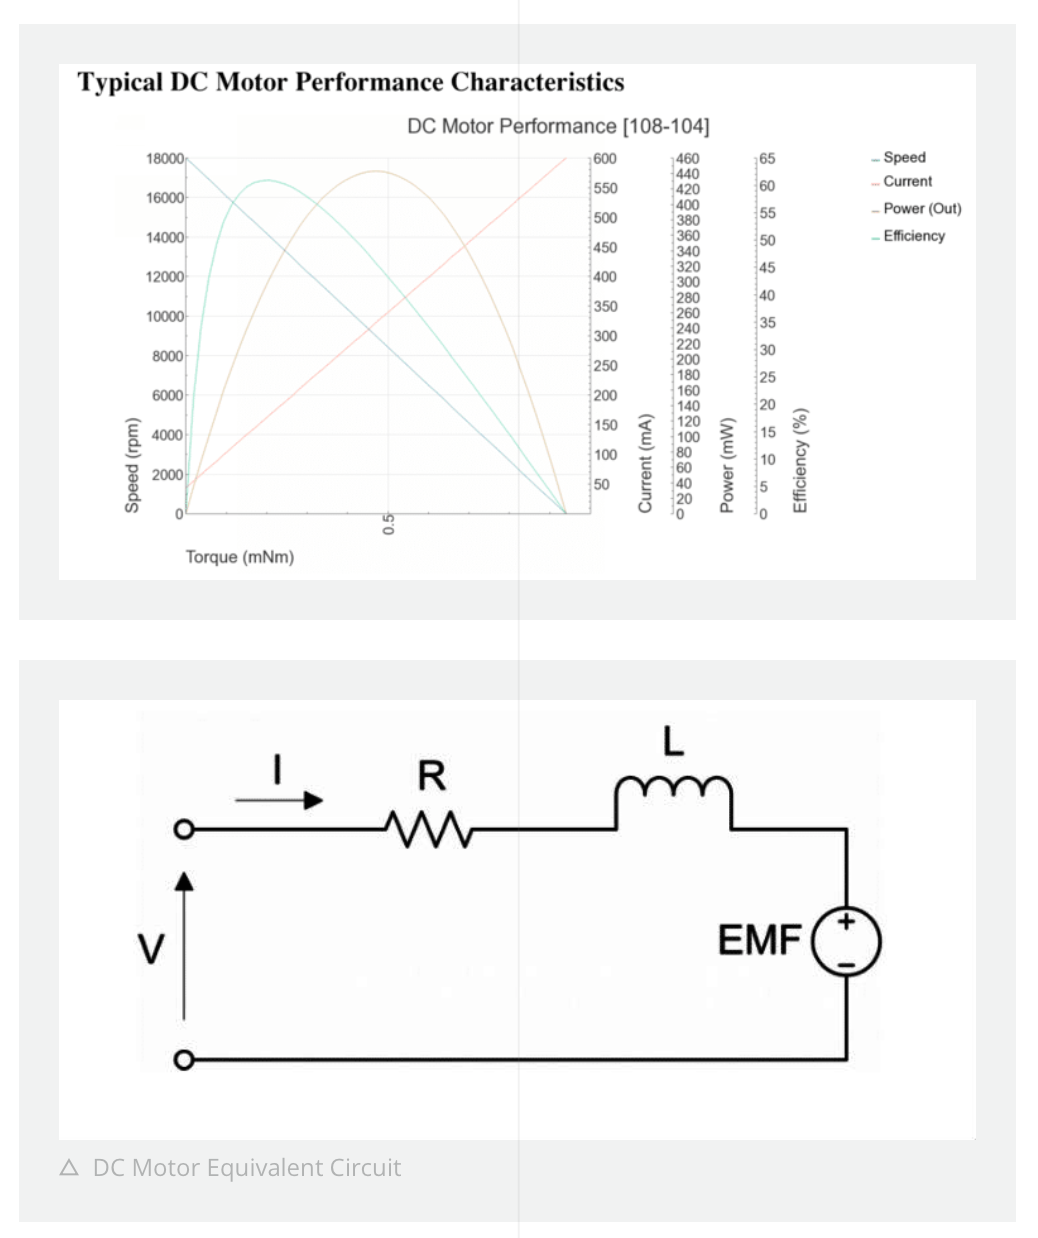

https://www.precisionmicrodrives.com/dc-motor-speed-voltage-and-torque-relationships

DC Motor Speed: Voltage and Torque Relationships
Something we have discussed in the past is how varying the voltage to a vibration motor can change the amplitude, particularly with reference to haptic feedback and playing different effects. However, something we haven’t explicitly shown is why this happens, or discussed it in the context of a normal DC motor. So in this short article, we will demonstrate how an increased voltage will increase the speed and an increased load will decrease the speed of a motor.

It is important to note that this is valid for all of our products that are based on brushed DC motors, so it applies to:

DC motors, directly
DC gearmotors, directly with a simple mechanical speed reduction
Vibration motors, which have a fixed load
We start with the equivalent circuit of a brushed DC motor:

A typical DC motor performance graph using the 108-104
a DC motor equivalent circuit
DC Motor Equivalent Circuit
Using a simple voltage loop we can see that the input voltage (\(V)\) is equal to the voltage drop across the coil resistance (\(R)\) and the inductor (\(L)\), with the back EMF (\(E)\) produced by the motor in motion, i.e.:

$$V = IR + L \frac{dI}{dt} + E$$

However, to demonstrate the effect voltage and torque have on speed, we are only concerned with steady-state behaviour at the moment. In steady-state we benefit from two simplifications:

First, the current is constant which means the inductor \( L\) can be removed
Secondly, as there is no change in speed, the torque produced by the motor and the torque produced by the load must be equal
The second simplification helps as we consider how torque is produced in the motor, given by the following equation:

$$T = K_{T} \phi I$$

Where \(K_{T}\) represents a constant inherited from its internal design, \(\phi\) is the total flux and \(T\) can represent our load torque. We rearrange this for \(I\) and enter it into our original equation:

$$V = \frac{T}{K_{T} \phi} R + E$$

Now we turn our attention to the emf \(E\), which is dependent upon the total flux \(\phi\) motor specific factors (such as its radius and length) that make a second constant \(K_{E}\) and the speed of the motor \(n\):

$$E = K_{E} \phi n$$

Substituting this value of \(E\) into our equation yields the following:

$$V = \frac{T}{K_{T} \phi} R + K_{E} \phi n$$

The equation above actually represents a linear motor, in adapting this to an angular rotating motor we consider the flux to be constant at its full value. In doing so it is combined with each constant to produce the torque constant and electrical constant of the motor, denoted \(k_{t}\) and \(k_{e}\) respectively. As discussed before, these constants actually share the same units, so we can replace both constants in our equation to the value \(k\). Also, we now replace linear speed \(n\) with angular velocity \(\omega\), so our equation becomes:

$$V = \frac{T}{k} R + k \omega$$

Rearranged for angular velocity:

$$\omega = \frac{V}{k} – \frac {T}{k^{2}} R$$

In summary, we can highlight the two main variables which affect the speed of the motor in our final equation:

Input Voltage:  For a fixed load, the speed of the motor is affected by the applied voltage. Increase in voltage = increase in speed
Load Torque: For a fixed voltage, the speed of the motor is inversely affected by the load. Increase in load torque = decrease in speed
If you have any questions about this relationship, or how the theory applies to a ‘real-world’ motor, please contact our sales engineers to help with your application.

In [39]:
# https://docs.sympy.org/latest/guides/solving/find-roots-polynomial.html
# https://stackoverflow.com/questions/22089150/factor-to-complex-roots-using-sympy
s = sym.Symbol('s')
sym.factor(s**2+1, gaussian=True)

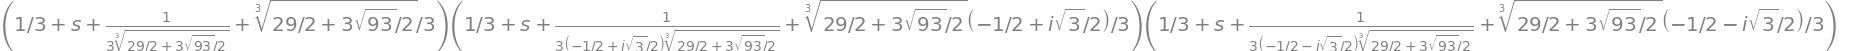

In [44]:
#sym.factor(, gaussian=True)
p = s**3 + s**2 + 1
r = sym.roots(p, s)
sym.LC(p, s)*sym.Mul(*[(s - a)**r[a] for a in r])

In [45]:
sym.roots(s**2+1, s)

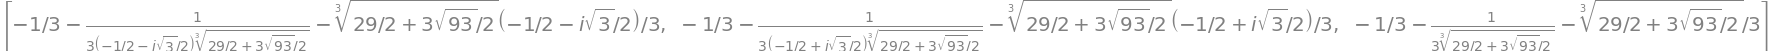

In [48]:
sym.solve(p, s, quartics=False)

In [58]:
# https://stackoverflow.com/questions/69400843/how-to-get-repeating-roots-in-sympy
    
eqn = s**2 - 2*s + 1
#sym.solveset(eqn, s)
eqn.as_poly()
r = sym.roots(eqn.as_poly())
r

In [59]:
sym.LC(eqn, s)*sym.Mul(*[(s - a)**r[a] for a in r])

In [60]:
(-1 + s) * (-1 + s)

In [61]:
eqn

In [64]:
eqn = s**2 - 8*s + 16
eqn

In [65]:
sym.roots(eqn)

In [66]:
# https://en.wikipedia.org/wiki/Damping